In [13]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [14]:
BASE_PATH = Path("data/beto_carrero_world/")

In [15]:
def load_data(file_path):
  files = sorted(list(file_path.glob("**/*.csv")))
  
  print(f"Found {len(files)} CSV files in {file_path}")
  
  if not files:
    print("No CSV files found in the specified directory.")
    return None
  
  dfs_list = []
  
  for file in files:
    year = file.parent.name
    month = file.stem
    
    try:
      temp_df = pd.read_csv(file)
      temp_df["year_file"] = year
      temp_df["month_file"] = month
      
      dfs_list.append(temp_df)
      print(f"Loaded {year}/{month} successfully. {len(temp_df)} records")
    except Exception as e:
      print(f"Error loading {year}/{month}: {e}")
  
  final_df = pd.concat(dfs_list, ignore_index=True)
  
  if 'last_updated_api' in final_df.columns:
    final_df['last_updated_api'] = pd.to_datetime(final_df['last_updated_api'])
    
  return final_df
 
 

In [16]:
df = load_data(BASE_PATH)

Found 40 CSV files in data\beto_carrero_world
Loaded 2023/01 successfully. 70959 records
Loaded 2023/02 successfully. 64092 records
Loaded 2023/03 successfully. 70959 records
Loaded 2023/04 successfully. 68670 records
Loaded 2023/05 successfully. 70959 records
Loaded 2023/06 successfully. 68670 records
Loaded 2023/07 successfully. 70959 records
Loaded 2023/08 successfully. 70959 records
Loaded 2023/09 successfully. 68670 records
Loaded 2023/10 successfully. 70959 records
Loaded 2023/11 successfully. 68670 records
Loaded 2023/12 successfully. 70959 records
Loaded 2024/01 successfully. 70959 records
Loaded 2024/02 successfully. 66381 records
Loaded 2024/03 successfully. 70959 records
Loaded 2024/04 successfully. 68670 records
Loaded 2024/05 successfully. 70959 records
Loaded 2024/06 successfully. 68670 records
Loaded 2024/07 successfully. 70959 records
Loaded 2024/08 successfully. 70959 records
Loaded 2024/09 successfully. 68670 records
Loaded 2024/10 successfully. 70959 records
Loaded 2

In [17]:
df

,id,name,is_open,wait_time,data_local,hora_local,year_file,month_file
0,11329.0,Autopista (bate-bate),False,0,2023-01-01,10:00:00,2023,01
1,11329.0,Autopista (bate-bate),False,0,2023-01-01,10:05:00,2023,01
2,11329.0,Autopista (bate-bate),False,0,2023-01-01,10:10:00,2023,01
3,11329.0,Autopista (bate-bate),False,0,2023-01-01,10:15:00,2023,01
4,11329.0,Autopista (bate-bate),False,0,2023-01-01,10:20:00,2023,01
...,...,...,...,...,...,...,...,...
2566134,12326.0,Super Soaker Splash,True,5,2026-04-08,18:55:04,2026,04
2566135,11336.0,Tchibum,True,40,2026-04-08,18:55:04,2026,04
2566136,11332.0,Tigor Mountain,True,5,2026-04-08,18:55:04,2026,04
2566137,15407.0,Turbo Drive,True,35,2026-04-08,18:55:06,2026,04


In [18]:
# 1. Criar o DF de espera média diária a partir do seu DF novo
# Usamos 'data_local' que você já tem tratada
espera_media = df[df['wait_time'] > 0].groupby('data_local')['wait_time'].mean().reset_index()
espera_media['wait_time'] = espera_media['wait_time'].round(0).astype(int)

In [21]:
# 2. Extrair componentes de data
espera_media['date'] = pd.to_datetime(espera_media['data_local'], format='mixed')
espera_media['year'] = espera_media['date'].dt.year
espera_media['month'] = espera_media['date'].dt.month
espera_media['day'] = espera_media['date'].dt.day
espera_media['day_of_week'] = espera_media['date'].dt.day_name()
espera_media['week_of_year'] = espera_media['date'].dt.isocalendar().week

In [22]:
# 3. Ajuste para os primeiros dias de Janeiro (evitar semana 52/53 no início do ano)
primeiros_dias_janeiro = (espera_media['month'] == 1) & (espera_media['week_of_year'] > 50)
espera_media.loc[primeiros_dias_janeiro, 'week_of_year'] = 0

In [23]:
# 4. Cálculo dos Percentis Globais (baseado nos novos dados)
p5 = np.percentile(espera_media['wait_time'], 5)
p90 = np.percentile(espera_media['wait_time'], 90)
p95 = np.percentile(espera_media['wait_time'], 95)

In [24]:
def custom_color_map(value):
    if value > p95:
        return 'black'
    else:
        # Garante que o valor não quebre a normalização
        val = max(p5, min(value, p95))
        norm_value = (val - p5) / (p95 - p5)
        return plt.cm.RdYlGn_r(norm_value)

In [25]:
def gera_calendario(df_espera, ano_selecionado=2024):
    espera = df_espera[df_espera['year'] == ano_selecionado].copy()
    espera['date'] = pd.to_datetime(espera['date'])
    
    # --- AJUSTE CRUCIAL: %W considera que a semana começa na SEGUNDA-FEIRA ---
    espera['custom_week'] = espera['date'].apply(lambda x: x.strftime('%W')).astype(int)
    
    if espera.empty:
        print(f"Sem dados para o ano {ano_selecionado}")
        return

    # Pivot Table
    pivot_df = espera.pivot_table(values='wait_time', index='custom_week', columns='day_of_week', aggfunc=np.mean)
    
    # Garantir a ordem: Segunda a Domingo
    ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    for day in ordered_days:
        if day not in pivot_df.columns:
            pivot_df[day] = np.nan
    pivot_df = pivot_df[ordered_days]

    # Matriz de anotações e identificação de meses
    annotation_array = []
    meses_da_semana = {}
    
    for week in pivot_df.index:
        annotation_row = []
        meses_vistos = set()
        for day in ordered_days:
            date_row = espera[(espera['custom_week'] == week) & (espera['day_of_week'] == day)]
            if not date_row.empty:
                d, m, w = date_row.iloc[0]['day'], date_row.iloc[0]['month'], date_row.iloc[0]['wait_time']
                annotation_row.append(f"{d}/{m}\n{int(w)}")
                meses_vistos.add(m)
            else:
                annotation_row.append('')
        
        annotation_array.append(annotation_row)
        # Só rotula o mês se a semana for majoritariamente ou totalmente daquele mês
        if len(meses_vistos) == 1:
            meses_da_semana[week] = list(meses_vistos)[0]
        elif len(meses_vistos) > 1:
            # Se a semana é dividida, pegamos o mês que tem mais dias nela
            # (Isso evita que o nome do mês suba cedo demais)
            mais_comum = espera[espera['custom_week'] == week]['month'].mode()[0]
            meses_da_semana[week] = mais_comum

    annotation_array = np.array(annotation_array)
    pivot_df_inv = pivot_df.iloc[::-1]
    annot_inv = annotation_array[::-1]

    altura_dinamica = len(pivot_df_inv) * 0.95 
    plt.figure(figsize=(16, altura_dinamica))

    meses_ja_rotulados = set()
    nome_meses = {1:'JANEIRO', 2:'FEVEREIRO', 3:'MARÇO', 4:'ABRIL', 5:'MAIO', 6:'JUNHO', 
                  7:'JULHO', 8:'AGOSTO', 9:'SETEMBRO', 10:'OUTUBRO', 11:'NOVEMBRO', 12:'DEZEMBRO'}

    for i, week_idx in enumerate(pivot_df_inv.index):
        for j, day in enumerate(pivot_df_inv.columns):
            value = pivot_df_inv.loc[week_idx, day]
            info_cell = annot_inv[i, j]
            
            if info_cell != '':
                color = 'white' if value > p90 or value < 17 else 'black'
                info = info_cell.split('\n')
                
                plt.text(j + 0.8, i + 0.75, info[0], ha='center', va='center', fontsize=10, color=color)
                plt.text(j + 0.5, i + 0.35, info[1], ha='center', va='center', fontsize=16, fontweight='bold', color=color)

                plt.fill_betweenx([i, i+1], j, j+1, color=custom_color_map(value))
                plt.plot([j, j+1, j+1, j, j], [i, i, i+1, i+1, i], color='white', linewidth=1.5)

        # Rótulo do Mês na direita
        if week_idx in meses_da_semana:
            m_num = meses_da_semana[week_idx]
            if m_num not in meses_ja_rotulados:
                plt.text(7.2, i + 0.5, nome_meses[m_num], va='center', ha='left', fontsize=13, fontweight='bold', color='darkblue')
                meses_ja_rotulados.add(m_num)

    plt.xticks(ticks=np.arange(0.5, 7), labels=['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo'])
    plt.yticks(ticks=np.arange(0.5, len(pivot_df_inv.index)), labels=pivot_df_inv.index)
    plt.title(f"Calendário Beto Carrero - {ano_selecionado}", fontsize=20, pad=25)
    plt.xlim(0, 8.8)
    plt.tight_layout()
    plt.show()

C:\Users\Luis PC\AppData\Local\Temp\ipykernel_9080\2329441587.py:13: FutureWarning: The provided callable <function mean at 0x00000153A2FE0860> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = espera.pivot_table(values='wait_time', index='custom_week', columns='day_of_week', aggfunc=np.mean)


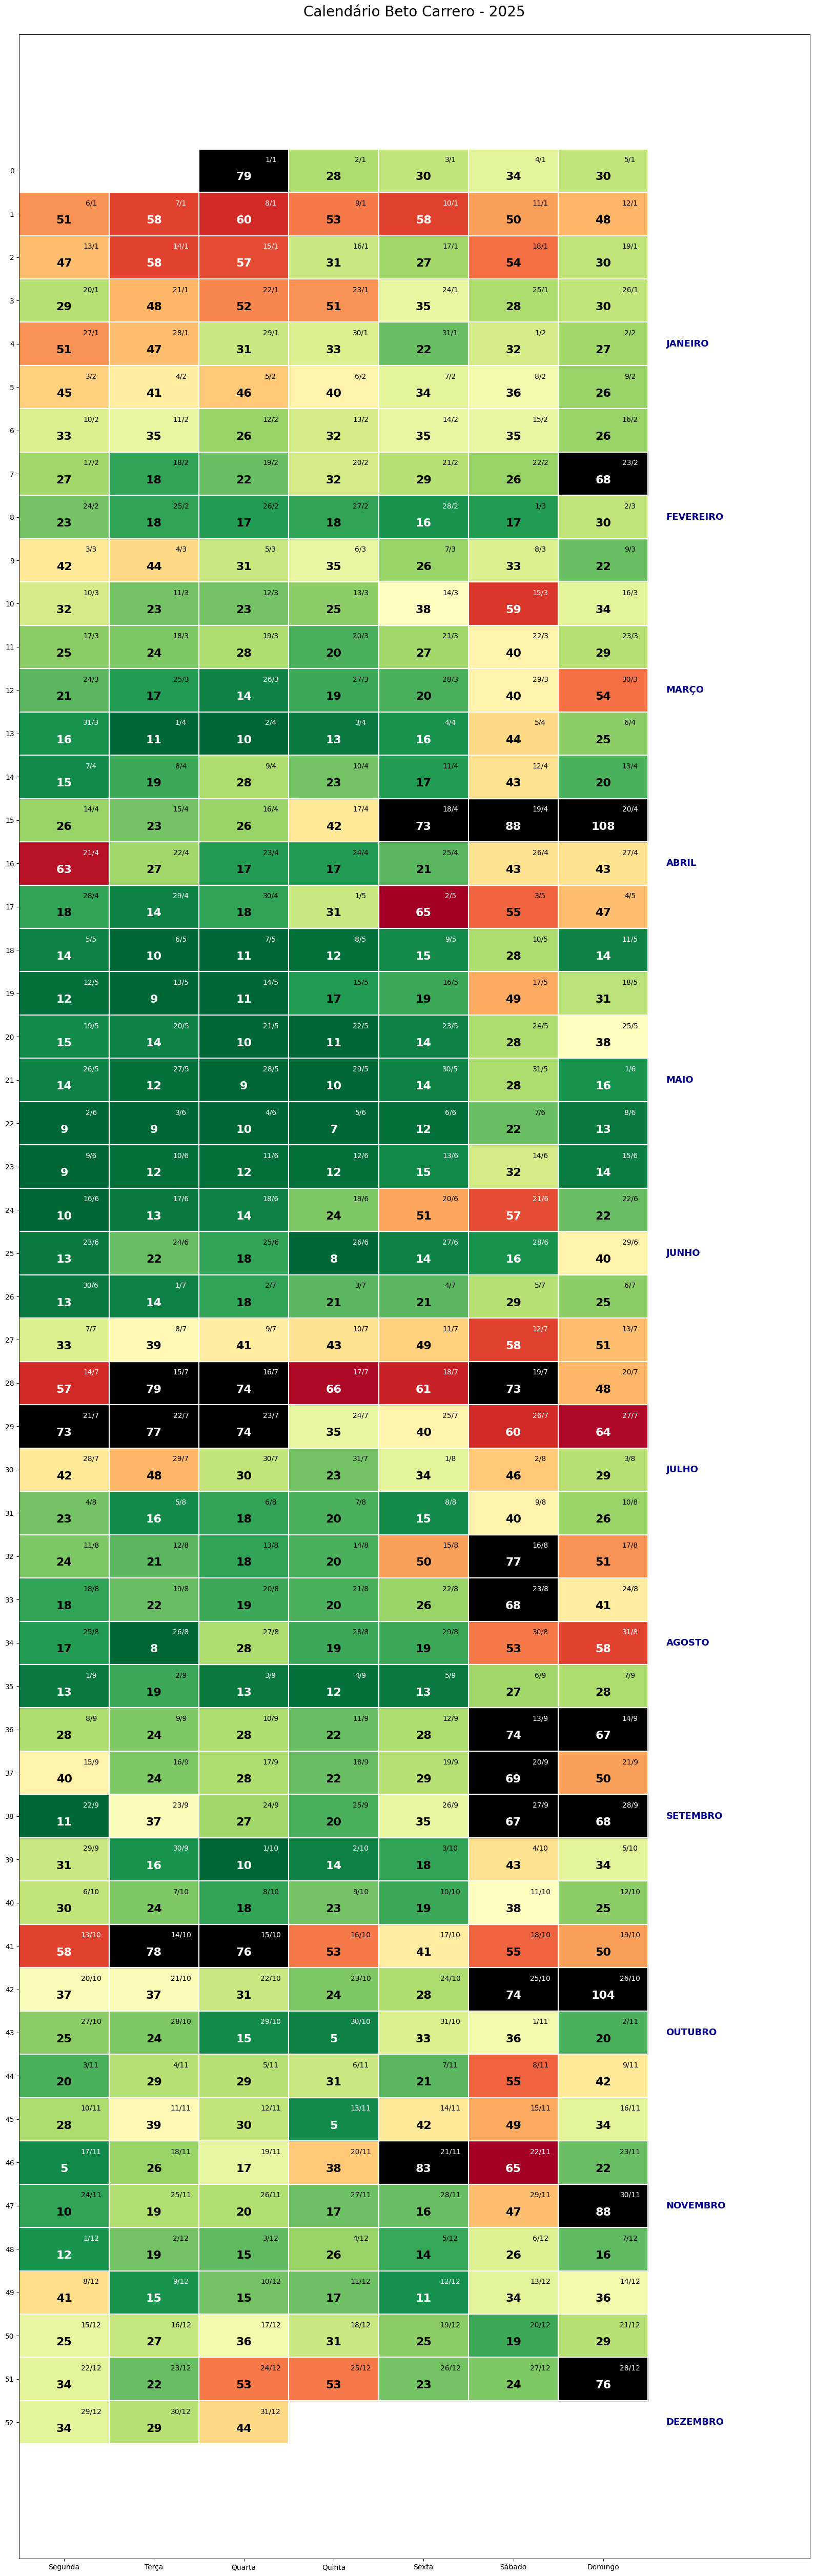

In [26]:
gera_calendario(espera_media, ano_selecionado=2025)

In [1]:
import pandas as pd
import os

def unificar_arquivos_por_ano():
    caminho_base = 'data/beto_carrero_world'
    anos = ['2023', '2024', '2025', '2026']

    for ano in anos:
        lista_dfs_ano = []
        pasta_ano = os.path.join(caminho_base, ano)
        
        if os.path.exists(pasta_ano):
            print(f"Processando ano: {ano}...")
            for mes in range(1, 13):
                nome_arquivo = f"{mes:02d}.csv"
                caminho_arquivo = os.path.join(pasta_ano, nome_arquivo)
                
                if os.path.exists(caminho_arquivo):
                    df_temp = pd.read_csv(caminho_arquivo)
                    
                    # Padronização da data
                    if 'data_local' in df_temp.columns:
                        df_temp['data_local'] = pd.to_datetime(df_temp['data_local'], format='mixed').dt.date
                    
                    lista_dfs_ano.append(df_temp)
            
            if lista_dfs_ano:
                df_anual = pd.concat(lista_dfs_ano, ignore_index=True)
                df_anual = df_anual.sort_values(by='data_local')
                
                # Salva um arquivo para cada ano
                nome_saida = f'consolidado-bcw-{ano}.csv'
                df_anual.to_csv(nome_saida, index=False, encoding='utf-8-sig')
                print(f"Salvo: {nome_saida} ({len(df_anual)} linhas)")
        else:
            print(f"Aviso: Pasta {ano} não encontrada.")

unificar_arquivos_por_ano()

Processando ano: 2023...
Salvo: consolidado-bcw-2023.csv (835485 linhas)
Processando ano: 2024...
Salvo: consolidado-bcw-2024.csv (837774 linhas)
Processando ano: 2025...
Salvo: consolidado-bcw-2025.csv (693303 linhas)
Processando ano: 2026...
Salvo: consolidado-bcw-2026.csv (199577 linhas)
